# 🏠 Multimodal ML — Housing Price Prediction
### Images + Tabular Data  →  Combined Deep Learning Model

**Objective:** Predict house prices by fusing features from **house images (CNN)** with **structured tabular data (MLP)** into a single end-to-end model.

**Pipeline overview:**
```
House Images  ──►  MobileNetV2 (CNN)  ──►  Image Feature Vector ─────┐
                                                                       ├──► Fusion MLP ──► Price ($)
Tabular Data  ──►  Normalisation + MLP  ──►  Tabular Feature Vector ──┘
```

**Skills:** CNNs · Transfer Learning · Feature Fusion · Multimodal Regression · MAE & RMSE evaluation


## 📦 Step 1 — Install & Import Libraries

In [1]:
# All pre-installed on Colab; uncomment if running locally
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn Pillow --quiet


In [2]:
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageDraw, ImageFilter
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"✅  TensorFlow {tf.__version__}  |  GPU: {len(tf.config.list_physical_devices('GPU'))} device(s)")


✅  TensorFlow 2.20.0  |  GPU: 1 device(s)


In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
IMG_DIR   = "house_images"          # folder that will hold .jpg files
IMG_SIZE  = (128, 128)              # resize target for CNN input
N_SAMPLES = 1200                    # synthetic dataset size

os.makedirs(IMG_DIR, exist_ok=True)
print(f"Image directory: '{IMG_DIR}/'")


Image directory: 'house_images/'


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# OPTION A  ←  uncomment if you have real data
# ══════════════════════════════════════════════════════════════════════════════
# df = pd.read_csv("train.csv")
# df["image_path"] = df["Id"].apply(lambda i: f"images/{i}.jpg")
# df = df[df["image_path"].apply(os.path.exists)]   # keep only rows with images
# df.rename(columns={"SalePrice": "price"}, inplace=True)
# print(f"Real dataset loaded: {df.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# OPTION B  ←  synthetic dataset (default)
# ══════════════════════════════════════════════════════════════════════════════
def generate_house_image(house_id, sqft, condition, bedrooms, save_dir):
    """
    Render a simple 2D house schematic whose visual cues correlate with price:
      - Larger sqft  → wider / taller structure
      - Better condition → brighter palette
      - More bedrooms → more windows
    """
    W, H = 256, 256
    img  = Image.new("RGB", (W, H), color=(135, 180, 220))   # sky
    draw = ImageDraw.Draw(img)

    # Condition palette (poor=grey, good=warm)
    palettes = {
        1: [(120,120,120),(80,80,80),(60,60,60)],
        2: [(160,130,100),(120,100,80),(80,70,60)],
        3: [(200,170,130),(160,130,100),(100,90,80)],
        4: [(220,190,150),(180,150,110),(120,110,90)],
        5: [(240,210,170),(200,170,130),(140,120,100)],
    }
    wall_c, roof_c, door_c = palettes.get(condition, palettes[3])

    # House dimensions driven by sqft
    scale  = 0.4 + 0.4 * min(sqft / 4000, 1.0)
    bw     = int(W * scale)                 # body width
    bh     = int(H * 0.35 * scale)         # body height
    bx     = (W - bw) // 2                 # body x start
    by     = H - bh - 40                   # body y start (above ground)

    # Ground
    draw.rectangle([0, H - 40, W, H], fill=(80, 140, 80))

    # House body
    draw.rectangle([bx, by, bx+bw, by+bh], fill=wall_c, outline=(0,0,0), width=2)

    # Roof (triangle)
    roof_top = (W//2, by - int(bh * 0.6))
    draw.polygon([(bx-10, by), (bx+bw+10, by), roof_top], fill=roof_c, outline=(0,0,0))

    # Door
    dw, dh = max(18, bw//6), max(28, bh//2)
    dx = bx + bw//2 - dw//2
    dy = by + bh - dh
    draw.rectangle([dx, dy, dx+dw, dy+dh], fill=door_c, outline=(0,0,0))
    draw.ellipse([dx+dw-8, dy+dh//2-4, dx+dw-2, dy+dh//2+4], fill=(200,180,0))

    # Windows (one per bedroom, capped)
    n_win = min(int(bedrooms), 4)
    win_positions = np.linspace(bx + bw*0.12, bx + bw*0.88, n_win+2)[1:-1]
    ww, wh = max(14, bw//8), max(14, bh//4)
    wy = by + bh//5
    for wx in win_positions:
        wx = int(wx)
        draw.rectangle([wx, wy, wx+ww, wy+wh], fill=(200,230,255), outline=(0,0,0))
        draw.line([wx + ww//2, wy, wx + ww//2, wy+wh], fill=(0,0,0))
        draw.line([wx, wy + wh//2, wx+ww, wy + wh//2], fill=(0,0,0))

    # Subtle blur to look less mechanical
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))

    path = os.path.join(save_dir, f"{house_id}.jpg")
    img.save(path, quality=85)
    return path


# ── Generate tabular data ─────────────────────────────────────────────────────
np.random.seed(SEED)
neighbourhoods = ['Downtown', 'Suburbs', 'Riverside', 'Uptown', 'Eastside']
conditions     = [1, 2, 3, 4, 5]

records = []
for i in range(N_SAMPLES):
    bed   = np.random.randint(1, 7)
    bath  = round(np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4]), 1)
    sqft  = int(np.random.normal(1800, 600))
    sqft  = max(500, min(sqft, 5000))
    yr    = np.random.randint(1950, 2023)
    neigh = np.random.choice(neighbourhoods)
    cond  = np.random.choice(conditions, p=[0.05, 0.10, 0.35, 0.35, 0.15])
    gar   = np.random.choice([0, 1, 2])

    # Price formula: sqft + condition + neighbourhood premium + noise
    n_premium = {'Downtown':1.3,'Uptown':1.2,'Riverside':1.1,'Suburbs':1.0,'Eastside':0.9}
    base  = sqft * 120 * (cond / 3.0) * n_premium[neigh]
    base += bed * 5000 + bath * 8000 + gar * 12000
    base += (2023 - yr) * -200
    price = max(50000, base + np.random.normal(0, base * 0.08))

    records.append({
        'id': i, 'bedrooms': bed, 'bathrooms': bath, 'sqft': sqft,
        'year_built': yr, 'neighbourhood': neigh, 'condition': cond,
        'garage_cars': gar, 'price': round(price, 2)
    })

df = pd.DataFrame(records)

# ── Generate images (first run: ~30 seconds) ──────────────────────────────────
print("Generating house images …", end=" ")
paths = []
for _, row in df.iterrows():
    p = generate_house_image(row['id'], row['sqft'], row['condition'],
                              row['bedrooms'], IMG_DIR)
    paths.append(p)
df['image_path'] = paths

print(f"done.  Dataset shape: {df.shape}")
df.head(3)


Generating house images … done.  Dataset shape: (1200, 10)


,id,bedrooms,bathrooms,sqft,year_built,neighbourhood,condition,garage_cars,price,image_path
0,0,4,3.0,2126,1970,Suburbs,3,2,297133.27,house_images/0.jpg
1,1,3,3.0,2747,1971,Eastside,5,1,567909.89,house_images/1.jpg
2,2,6,1.5,1521,2007,Eastside,3,0,195502.02,house_images/2.jpg


## 🔍 Step 3 — Exploratory Data Analysis

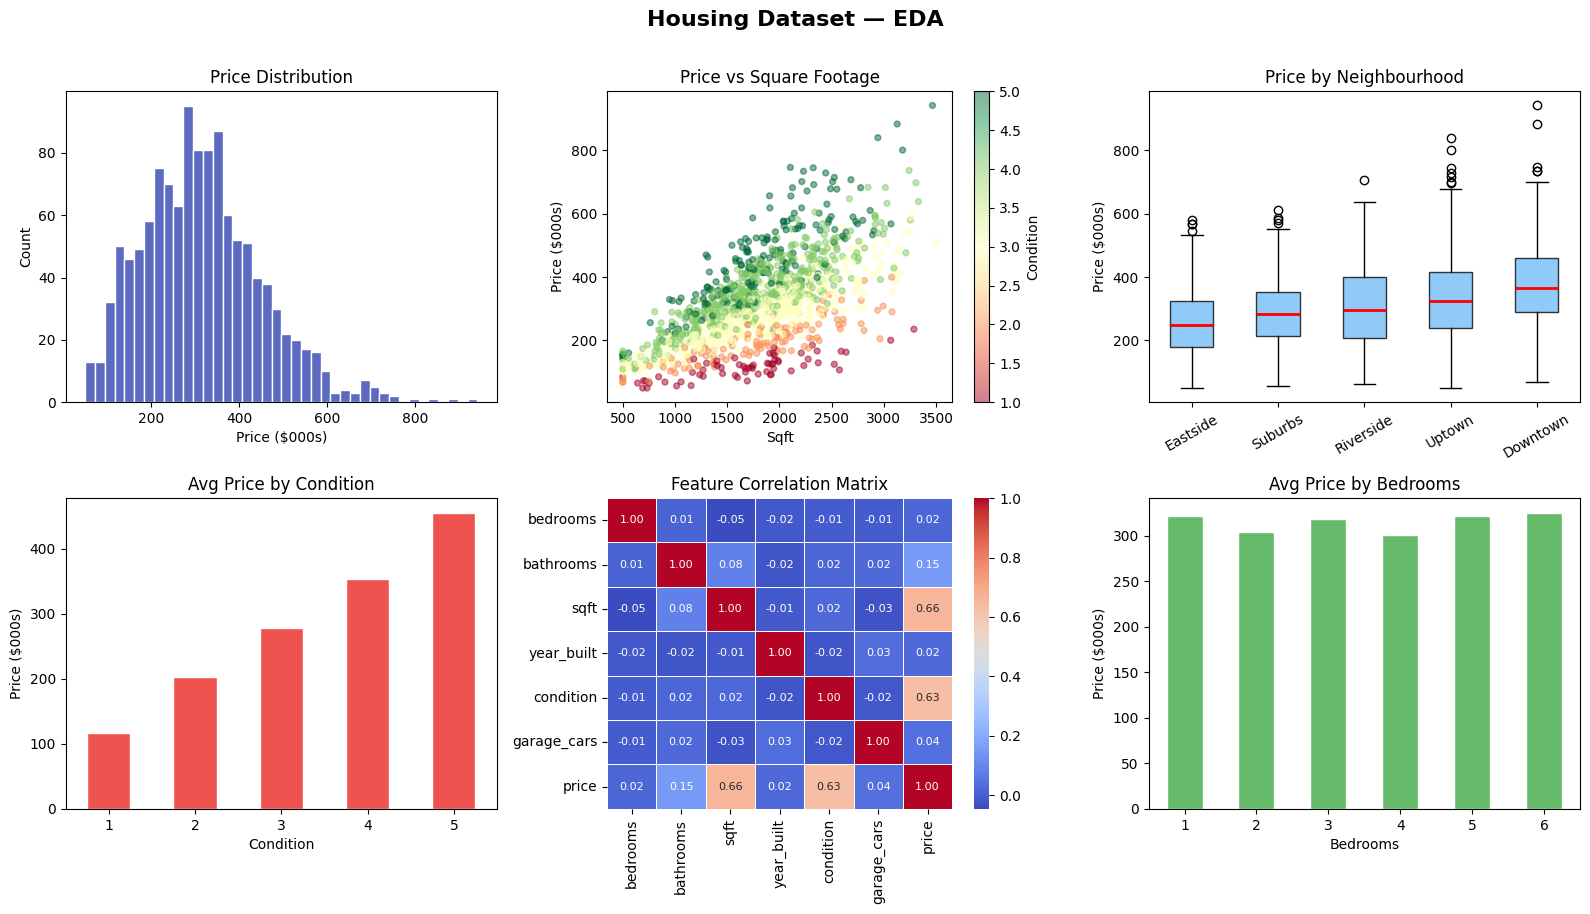

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Housing Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)

# Price distribution
axes[0,0].hist(df['price']/1000, bins=40, color='#5C6BC0', edgecolor='white')
axes[0,0].set(title='Price Distribution', xlabel='Price ($000s)', ylabel='Count')

# Price vs sqft
sc = axes[0,1].scatter(df['sqft'], df['price']/1000, c=df['condition'],
                        cmap='RdYlGn', alpha=0.5, s=18)
plt.colorbar(sc, ax=axes[0,1], label='Condition')
axes[0,1].set(title='Price vs Square Footage', xlabel='Sqft', ylabel='Price ($000s)')

# Price by neighbourhood — reorder data manually (boxplot has no "order" param)
order = df.groupby('neighbourhood')['price'].median().sort_values().index.tolist()
plot_data = [df.loc[df['neighbourhood'] == n, 'price'].values / 1000 for n in order]
axes[0,2].boxplot(plot_data, labels=order, patch_artist=True,
                  boxprops=dict(facecolor='#90CAF9', color='#333'),
                  medianprops=dict(color='red', linewidth=2))
axes[0,2].set(title='Price by Neighbourhood', xlabel='', ylabel='Price ($000s)')
axes[0,2].tick_params(axis='x', rotation=30)

# Price by condition
df.groupby('condition')['price'].mean().div(1000).plot(kind='bar', ax=axes[1,0],
    color='#EF5350', edgecolor='white', rot=0)
axes[1,0].set(title='Avg Price by Condition', xlabel='Condition', ylabel='Price ($000s)')

# Correlation heatmap
num_cols = ['bedrooms','bathrooms','sqft','year_built','condition','garage_cars','price']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size':8})
axes[1,1].set_title('Feature Correlation Matrix')

# Price by bedrooms
df.groupby('bedrooms')['price'].mean().div(1000).plot(kind='bar', ax=axes[1,2],
    color='#66BB6A', edgecolor='white', rot=0)
axes[1,2].set(title='Avg Price by Bedrooms', xlabel='Bedrooms', ylabel='Price ($000s)')

plt.tight_layout()
plt.show()


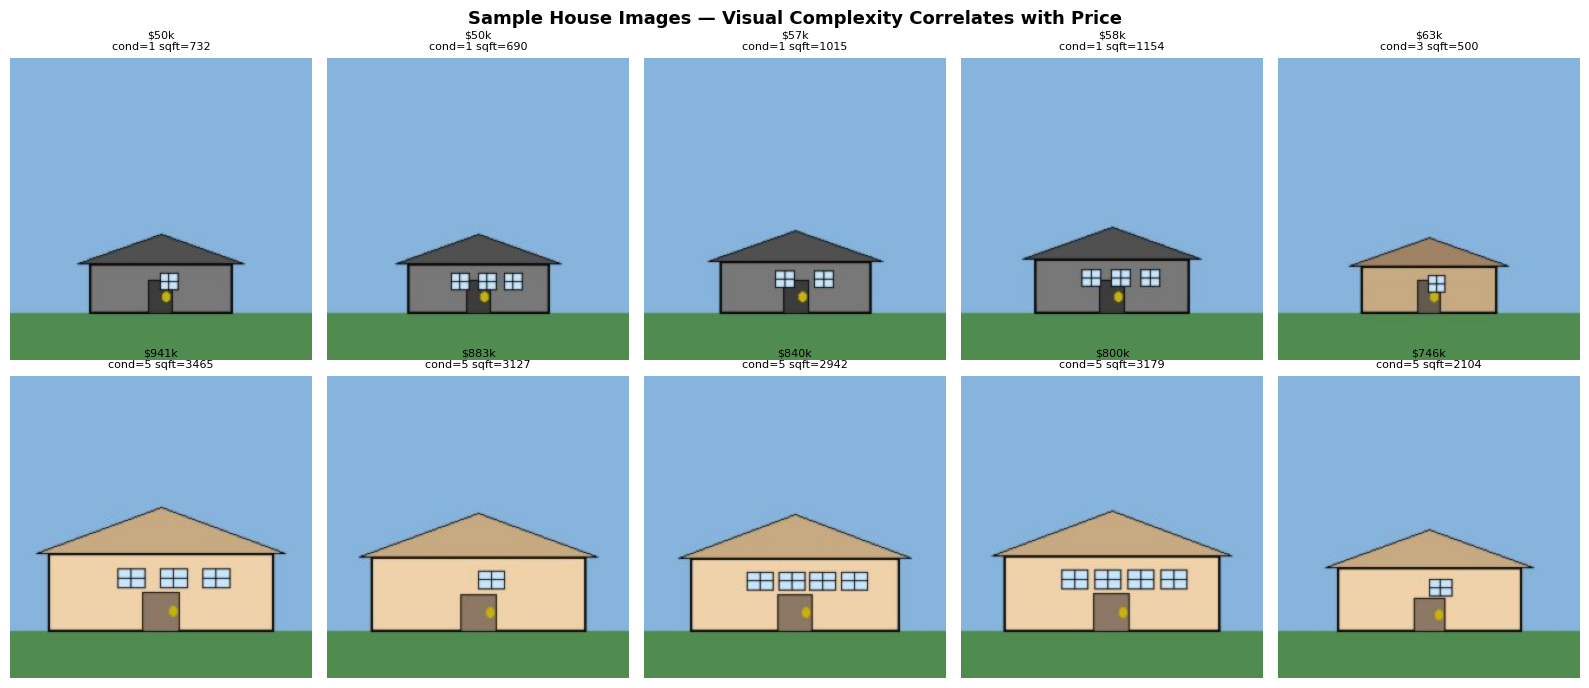

In [6]:
# Preview synthetic house images
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample House Images — Visual Complexity Correlates with Price',
             fontsize=13, fontweight='bold')

sample_df = pd.concat([df.nsmallest(5, 'price'), df.nlargest(5, 'price')], ignore_index=True)
for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    img = Image.open(row['image_path'])
    ax.imshow(img)
    ax.set_title(f"${row['price']/1000:.0f}k\ncond={row['condition']} sqft={row['sqft']}",
                 fontsize=8)
    ax.axis('off')

axes[0, 0].set_ylabel('Cheapest →', fontsize=10, labelpad=5)
axes[1, 0].set_ylabel('Most Expensive →', fontsize=10, labelpad=5)
plt.tight_layout()
plt.show()


## ✂️ Step 4 — Train / Validation / Test Split

We split first, then preprocess — this prevents **data leakage** from the scaler seeing test values.


In [7]:
TABULAR_NUM  = ['bedrooms', 'bathrooms', 'sqft', 'year_built', 'condition', 'garage_cars']
TABULAR_CAT  = ['neighbourhood']

X_tab = df[TABULAR_NUM + TABULAR_CAT]
X_img = df['image_path']
y     = df['price'].values.astype('float32')

# 70 % train  |  15 % val  |  15 % test
idx = np.arange(len(df))
idx_tv, idx_test = train_test_split(idx, test_size=0.15, random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, random_state=SEED)

print(f"Train : {len(idx_train):4d}  |  Val : {len(idx_val):4d}  |  Test : {len(idx_test):4d}")


Train :  840  |  Val :  180  |  Test :  180


## ⚙️ Step 5 — Tabular Data Preprocessing

In [8]:
# ── Fit preprocessor on TRAIN only ──────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                        TABULAR_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), TABULAR_CAT),
])

# Keep as DataFrame so ColumnTransformer can find columns by name
X_tab_train = preprocessor.fit_transform(X_tab.iloc[idx_train])
X_tab_val   = preprocessor.transform(X_tab.iloc[idx_val])
X_tab_test  = preprocessor.transform(X_tab.iloc[idx_test])

y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

TAB_DIM = X_tab_train.shape[1]
print(f"Tabular feature dimension after encoding: {TAB_DIM}")
cat_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(TABULAR_CAT))
print(f"All features ({TAB_DIM}): {TABULAR_NUM + cat_names}")


Tabular feature dimension after encoding: 11
All features (11): ['bedrooms', 'bathrooms', 'sqft', 'year_built', 'condition', 'garage_cars', 'neighbourhood_Downtown', 'neighbourhood_Eastside', 'neighbourhood_Riverside', 'neighbourhood_Suburbs', 'neighbourhood_Uptown']


## 🖼️ Step 6 — Image Data Pipeline (tf.data)

We use `tf.data` for efficient image loading:
- Resize to **128×128**
- Normalise pixels to **[0, 1]** (MobileNetV2 expects this when `preprocess_input` is used)
- Pair each image with its tabular features and price label


In [9]:
IMG_H, IMG_W = IMG_SIZE

def load_and_preprocess_image(path):
    raw   = tf.io.read_file(path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, [IMG_H, IMG_W])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def augment(image):
    """Light augmentation — flips + small brightness jitter."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def make_dataset(img_paths, tab_features, labels, training=False, batch_size=32):
    img_ds  = tf.data.Dataset.from_tensor_slices(img_paths)
    img_ds  = img_ds.map(load_and_preprocess_image,
                          num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        img_ds = img_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    tab_ds  = tf.data.Dataset.from_tensor_slices(tab_features.astype('float32'))
    lbl_ds  = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip(({'image_input': img_ds,
                                'tabular_input': tab_ds}, lbl_ds))
    if training:
        ds = ds.shuffle(buffer_size=512, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

BATCH = 32
train_ds = make_dataset(X_img.values[idx_train], X_tab_train, y_train, training=True,  batch_size=BATCH)
val_ds   = make_dataset(X_img.values[idx_val],   X_tab_val,   y_val,   training=False, batch_size=BATCH)
test_ds  = make_dataset(X_img.values[idx_test],  X_tab_test,  y_test,  training=False, batch_size=BATCH)

print(f"✅  Datasets ready  |  train batches: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")


✅  Datasets ready  |  train batches: 27  val: 6  test: 6


## 🧠 Step 7 — Build the Multimodal Model

### Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│  IMAGE BRANCH                                                        │
│  128×128×3 ──► MobileNetV2 (frozen ImageNet weights)                │
│              ──► GlobalAveragePooling2D  ──► 1280-d vector           │
│              ──► Dense(256, ReLU) + Dropout(0.3)  ──► 256-d         │
└───────────────────────────────────────────────┬─────────────────────┘
                                                │  Concatenate
┌───────────────────────────────────────────────┴─────────────────────┐
│  TABULAR BRANCH                                                      │
│  TAB_DIM ──► Dense(64, ReLU) ──► Dense(32, ReLU)  ──► 32-d         │
└─────────────────────────────────────────────────────────────────────┘
                         │
                    Fusion MLP
               Dense(128, ReLU) + Dropout(0.3)
               Dense(64, ReLU)
               Dense(1)  →  Predicted Price
```


In [10]:
def build_multimodal_model(tab_dim, img_shape=(IMG_H, IMG_W, 3)):

    # ── IMAGE BRANCH ──────────────────────────────────────────────────────────
    img_input = layers.Input(shape=img_shape, name='image_input')

    base_cnn = MobileNetV2(
        input_shape = img_shape,
        include_top = False,
        weights     = 'imagenet',     # transfer learning
    )
    base_cnn.trainable = False        # freeze in phase 1

    x_img = base_cnn(img_input, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(256, activation='relu', name='img_dense')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    # ── TABULAR BRANCH ────────────────────────────────────────────────────────
    tab_input = layers.Input(shape=(tab_dim,), name='tabular_input')
    x_tab = layers.Dense(64, activation='relu')(tab_input)
    x_tab = layers.BatchNormalization()(x_tab)
    x_tab = layers.Dense(32, activation='relu')(x_tab)

    # ── FUSION ────────────────────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([x_img, x_tab])
    x     = layers.Dense(128, activation='relu')(fused)
    x     = layers.Dropout(0.3)(x)
    x     = layers.Dense(64, activation='relu')(x)
    out   = layers.Dense(1, name='price_output')(x)

    model = Model(inputs=[img_input, tab_input], outputs=out,
                  name='MultimodalHousePriceModel')
    return model, base_cnn

model, base_cnn = build_multimodal_model(tab_dim=TAB_DIM)

model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'mse',
    metrics   = ['mae'],
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MultimodalHousePriceModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        768 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_dense (Dense)   │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ img_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 288)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     36,992 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         65 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,634,337 (10.05 MB)

 Trainable params: 376,225 (1.44 MB)

 Non-trainable params: 2,258,112 (8.61 MB)

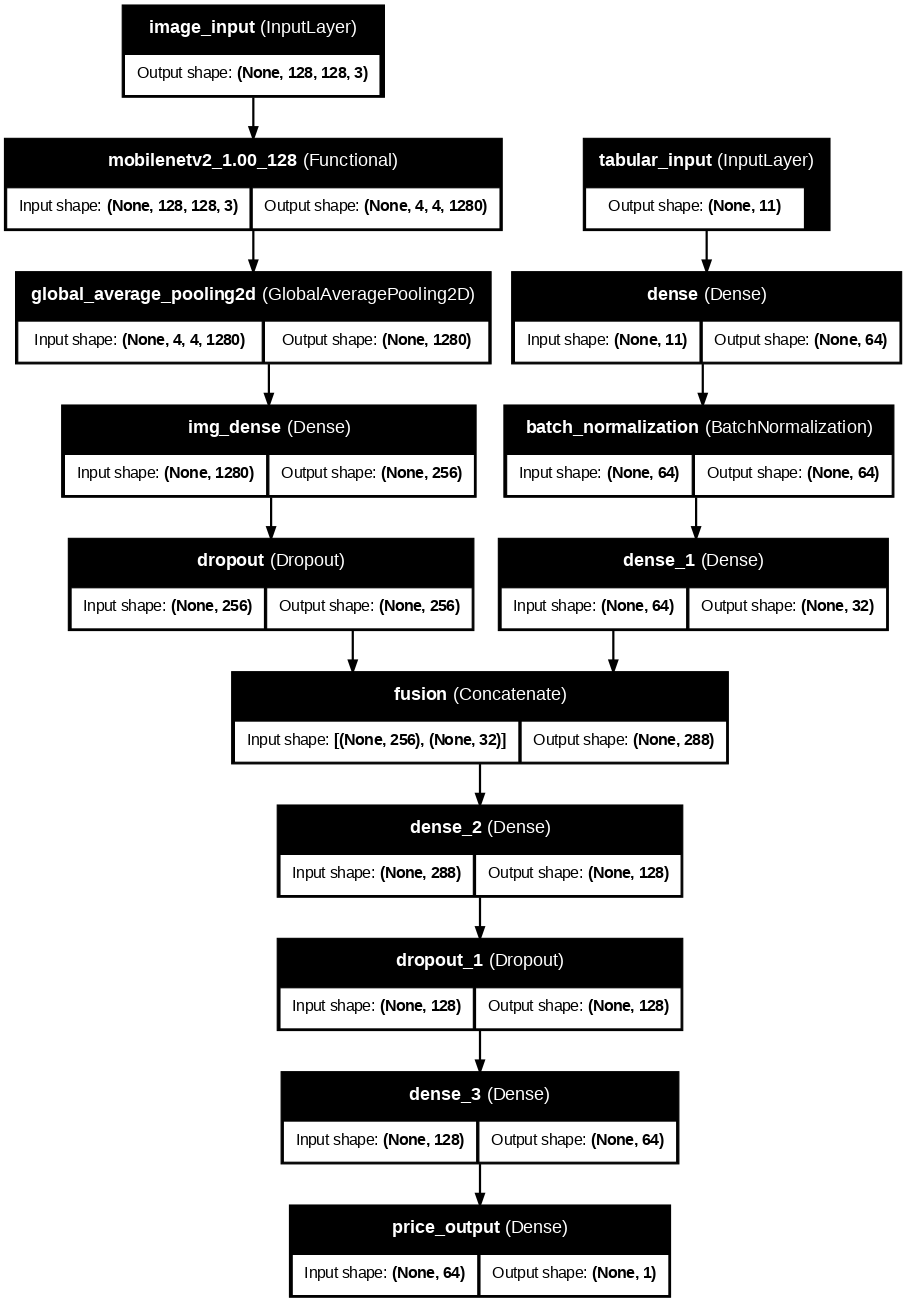

In [11]:
# Visualise model architecture
keras.utils.plot_model(
    model,
    to_file       = 'model_architecture.png',
    show_shapes   = True,
    show_layer_names = True,
    rankdir       = 'TB',
    dpi           = 80,
)
from IPython.display import Image as IPImage
IPImage('model_architecture.png')


## 🏋️ Step 8 — Training (Two-Phase)

**Phase 1 (10 epochs)** — CNN backbone frozen; only the fusion head and tabular branch train.  
**Phase 2 (fine-tuning, 10 epochs)** — Unfreeze the top layers of MobileNetV2 at a lower LR.


In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

# ── PHASE 1: frozen backbone ──────────────────────────────────────────────────
print("=" * 55)
print("  PHASE 1 — Training head (CNN backbone frozen)")
print("=" * 55)

history1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 10,
    callbacks       = callbacks,
    verbose         = 1,
)


  PHASE 1 — Training head (CNN backbone frozen)
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - loss: 117101813760.0000 - mae: 314829.6562 - val_loss: 118544449536.0000 - val_mae: 315510.5000 - learning_rate: 0.0010
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 115483967488.0000 - mae: 312210.6250 - val_loss: 113998446592.0000 - val_mae: 308228.9688 - learning_rate: 0.0010
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 103639785472.0000 - mae: 292299.5938 - val_loss: 89857048576.0000 - val_mae: 266260.2500 - learning_rate: 0.0010
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 64735961088.0000 - mae: 214619.7188 - val_loss: 36187873280.0000 - val_mae: 147054.0312 - learning_rate: 0.0010
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 23274295296.0000 - mae: 117329.1250 - val_loss: 17969516544.0000 - val_mae: 104878.3984 - learning_rate: 0.0010
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 17615396864.0000 - mae: 104667.562

In [13]:
# ── PHASE 2: fine-tune top CNN layers ────────────────────────────────────────
print("\n" + "=" * 55)
print("  PHASE 2 — Fine-tuning top CNN layers")
print("=" * 55)

# Unfreeze last 30 layers of MobileNetV2
base_cnn.trainable = True
for layer in base_cnn.layers[:-30]:
    layer.trainable = False

trainable_now = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreeze: {trainable_now}")

model.compile(
    optimizer = keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss      = 'mse',
    metrics   = ['mae'],
)

history2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 10,
    callbacks       = callbacks,
    verbose         = 1,
)



  PHASE 2 — Fine-tuning top CNN layers
Trainable layers after unfreeze: 14
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 652ms/step - loss: 11746249728.0000 - mae: 92670.0703 - val_loss: 15129624576.0000 - val_mae: 102269.9766 - learning_rate: 1.0000e-04
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 4452559360.0000 - mae: 51817.6016 - val_loss: 17376184320.0000 - val_mae: 112409.5234 - learning_rate: 1.0000e-04
Epoch 3/10
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3543501783.0400 - mae: 46110.4334
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 3092315648.0000 - mae: 42553.7969 - val_loss: 15837347840.0000 - val_mae: 107254.4922 - learning_rate: 1.0000e-04
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 2866325760.0000 - mae: 40237.4844 - val_loss: 18130409472.0000 - val_mae: 117026.6016 - learning_rate: 5.0000e-05
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 2226075392.0

## 📉 Step 9 — Training History Plots

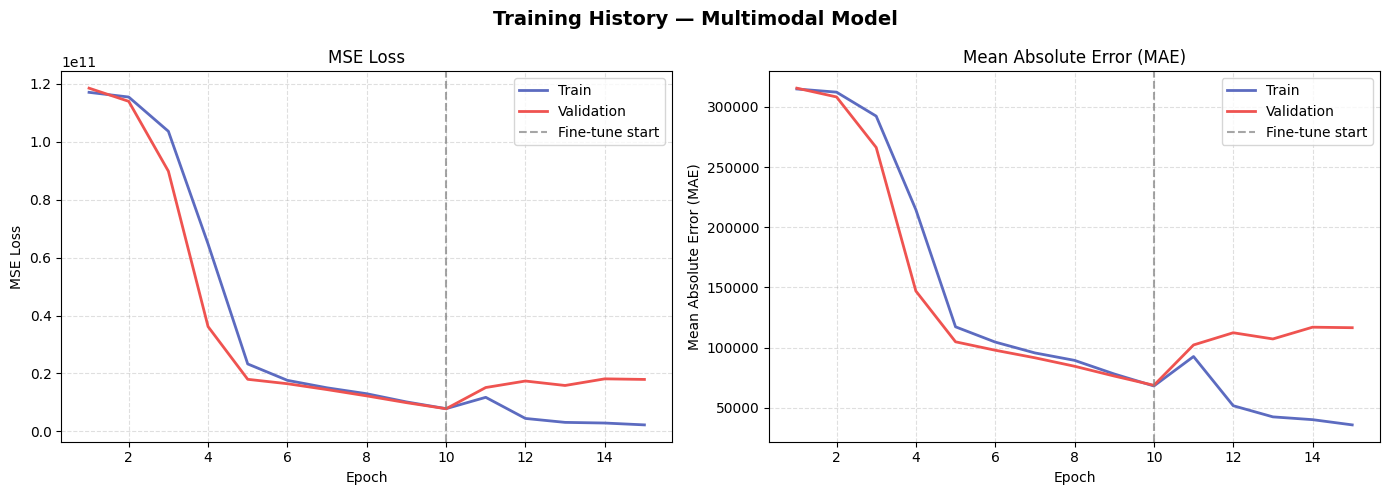

In [14]:
# Merge both phase histories
def merge_history(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

hist = merge_history(history1, history2)
phase1_end = len(history1.history['loss'])
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Multimodal Model', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes,
                              ['loss', 'mae'],
                              ['MSE Loss', 'Mean Absolute Error (MAE)']):
    ax.plot(epochs_range, hist[metric],     label='Train',      color='#5C6BC0', linewidth=2)
    ax.plot(epochs_range, hist[f'val_{metric}'], label='Validation', color='#EF5350', linewidth=2)
    ax.axvline(phase1_end, color='grey', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set(title=label, xlabel='Epoch', ylabel=label)
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 📊 Step 10 — Evaluate on Test Set (MAE & RMSE)

In [15]:
# ── Get predictions ──────────────────────────────────────────────────────────
y_pred_raw = model.predict(test_ds, verbose=0).flatten()
y_true     = y_test.copy()

# ── Metrics ──────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_true, y_pred_raw)
rmse = math.sqrt(mean_squared_error(y_true, y_pred_raw))
mape = np.mean(np.abs((y_true - y_pred_raw) / y_true)) * 100
r2   = 1 - np.sum((y_true - y_pred_raw)**2) / np.sum((y_true - np.mean(y_true))**2)

print("╔══════════════════════════════════════════╗")
print("║     TEST SET EVALUATION RESULTS          ║")
print("╠══════════════════════════════════════════╣")
print(f"║  MAE   (Mean Abs Error) : ${mae:>12,.0f}  ║")
print(f"║  RMSE  (Root Mean Sq E) : ${rmse:>12,.0f}  ║")
print(f"║  MAPE  (Mean Abs % Err) : {mape:>13.2f}%  ║")
print(f"║  R²    (Coeff of Det.)  : {r2:>14.4f}  ║")
print("╚══════════════════════════════════════════╝")


╔══════════════════════════════════════════╗
║     TEST SET EVALUATION RESULTS          ║
╠══════════════════════════════════════════╣
║  MAE   (Mean Abs Error) : $     103,226  ║
║  RMSE  (Root Mean Sq E) : $     124,439  ║
║  MAPE  (Mean Abs % Err) :         30.58%  ║
║  R²    (Coeff of Det.)  :         0.1918  ║
╚══════════════════════════════════════════╝


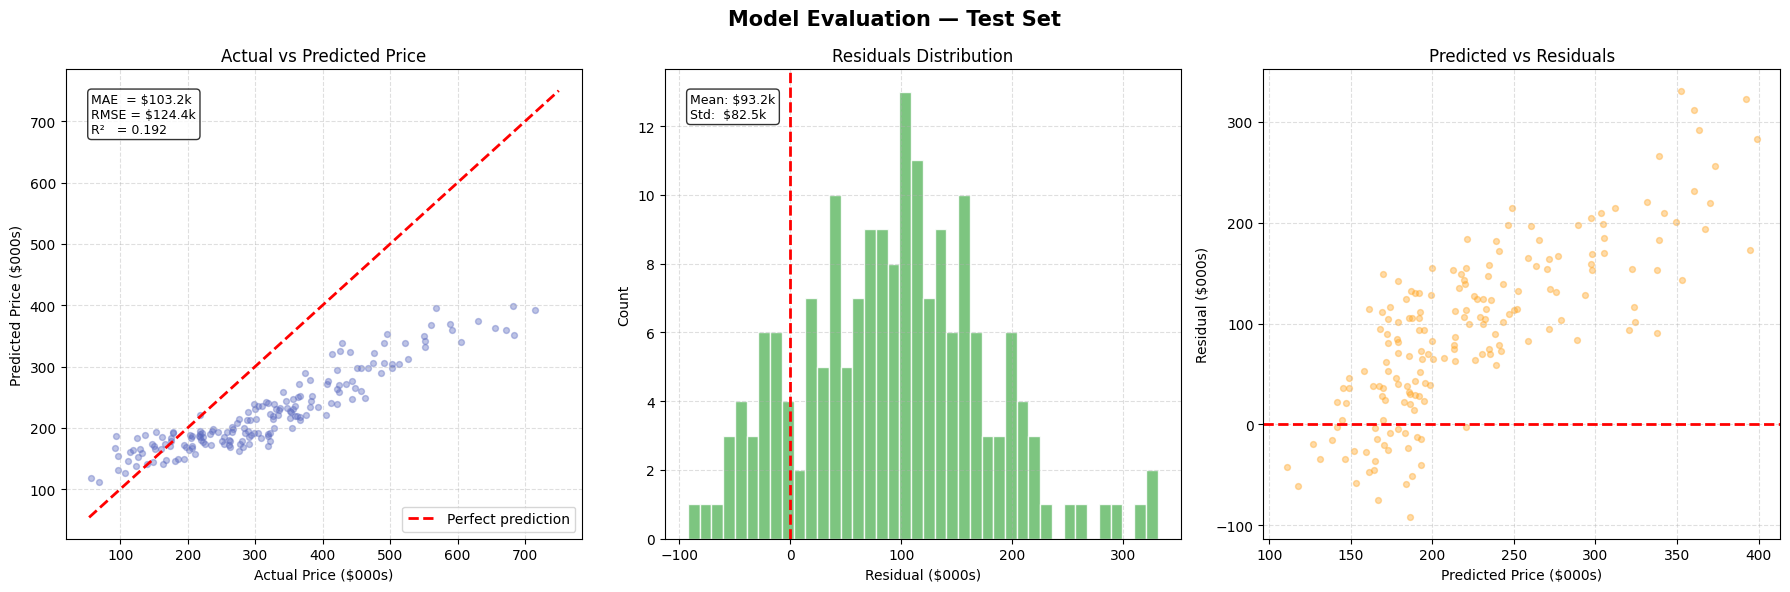

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Evaluation — Test Set', fontsize=15, fontweight='bold')

# 1) Actual vs Predicted scatter
lim_min = min(y_true.min(), y_pred_raw.min()) * 0.95
lim_max = max(y_true.max(), y_pred_raw.max()) * 1.05
axes[0].scatter(y_true/1000, y_pred_raw/1000, alpha=0.4, s=18, color='#5C6BC0')
axes[0].plot([lim_min/1000, lim_max/1000], [lim_min/1000, lim_max/1000],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set(title='Actual vs Predicted Price',
            xlabel='Actual Price ($000s)', ylabel='Predicted Price ($000s)')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

# Add metrics box
axes[0].text(0.05, 0.95, f'MAE  = ${mae/1000:.1f}k\nRMSE = ${rmse/1000:.1f}k\nR²   = {r2:.3f}',
             transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2) Residuals distribution
residuals = y_true - y_pred_raw
axes[1].hist(residuals/1000, bins=40, color='#66BB6A', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set(title='Residuals Distribution',
            xlabel='Residual ($000s)', ylabel='Count')
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].text(0.05, 0.95, f'Mean: ${residuals.mean()/1000:.1f}k\nStd:  ${residuals.std()/1000:.1f}k',
             transform=axes[1].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3) Predicted vs Residuals (check for heteroscedasticity)
axes[2].scatter(y_pred_raw/1000, residuals/1000, alpha=0.4, s=18, color='#FFA726')
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set(title='Predicted vs Residuals',
            xlabel='Predicted Price ($000s)', ylabel='Residual ($000s)')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 🔬 Step 11 — Sample Predictions with House Images

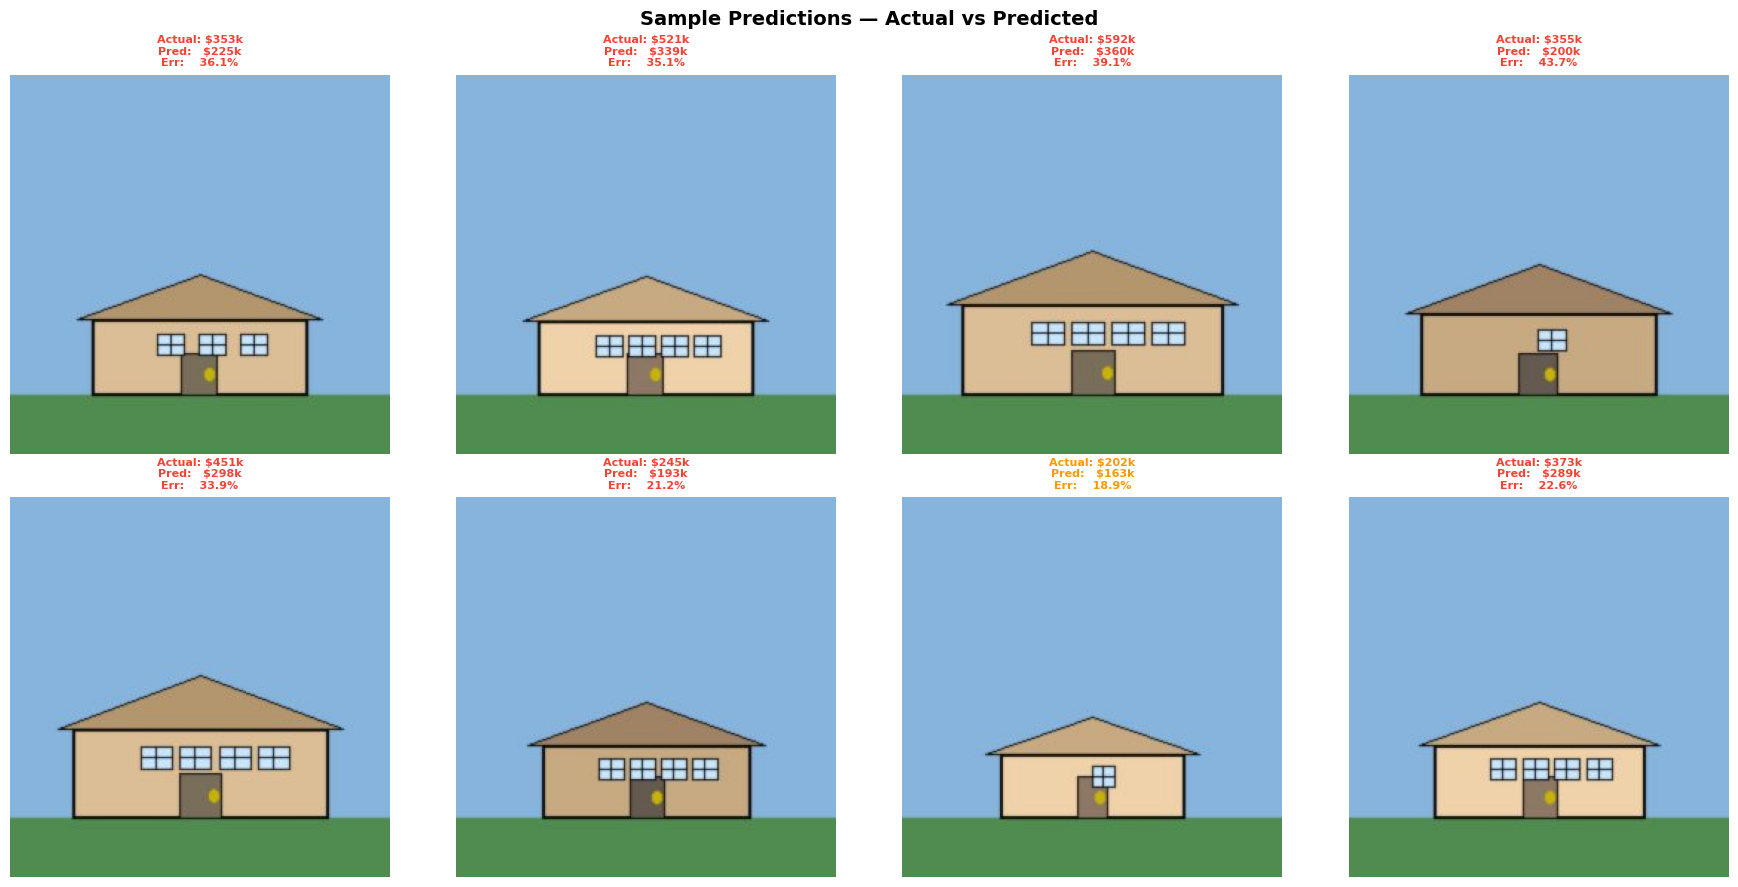

In [17]:
# Pick 8 random test samples and show the house image alongside the prediction
sample_idx = np.random.choice(len(idx_test), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Sample Predictions — Actual vs Predicted', fontsize=14, fontweight='bold')

for ax, si in zip(axes.flat, sample_idx):
    global_i = idx_test[si]
    img = Image.open(df['image_path'].iloc[global_i])
    ax.imshow(img)

    actual = y_true[si]
    pred   = y_pred_raw[si]
    err    = abs(actual - pred) / actual * 100

    color  = '#4CAF50' if err < 10 else ('#FF9800' if err < 20 else '#F44336')
    title  = (f"Actual: ${actual/1000:.0f}k\n"
              f"Pred:   ${pred/1000:.0f}k\n"
              f"Err:    {err:.1f}%")
    ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


## 🆚 Step 12 — Ablation Study: Image-Only vs Tabular-Only vs Multimodal

We train two simpler baseline models to prove that the multimodal fusion outperforms either modality alone.


In [18]:
# ── Tabular-only baseline ────────────────────────────────────────────────────
tab_input_bl = layers.Input(shape=(TAB_DIM,), name='tabular_input')
x = layers.Dense(64, activation='relu')(tab_input_bl)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(1)(x)
tab_model = Model(inputs=tab_input_bl, outputs=x, name='TabularOnly')

tab_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

tab_train = tf.data.Dataset.from_tensor_slices(
    (X_tab_train.astype('float32'), y_train)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
tab_val   = tf.data.Dataset.from_tensor_slices(
    (X_tab_val.astype('float32'),   y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
tab_test  = tf.data.Dataset.from_tensor_slices(
    (X_tab_test.astype('float32'),  y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("Training tabular-only baseline …")
tab_model.fit(tab_train, validation_data=tab_val, epochs=20,
              callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)

tab_preds = tab_model.predict(tab_test, verbose=0).flatten()
tab_mae   = mean_absolute_error(y_test, tab_preds)
tab_rmse  = math.sqrt(mean_squared_error(y_test, tab_preds))
print(f"  Tabular-only  →  MAE: ${tab_mae:,.0f}   RMSE: ${tab_rmse:,.0f}")


Training tabular-only baseline …
  Tabular-only  →  MAE: $315,003   RMSE: $343,551


In [19]:
# ── Image-only baseline ──────────────────────────────────────────────────────
img_input_bl = layers.Input(shape=(IMG_H, IMG_W, 3), name='image_input')
cnn_bl = MobileNetV2(input_shape=(IMG_H, IMG_W, 3), include_top=False, weights='imagenet')
cnn_bl.trainable = False

x = cnn_bl(img_input_bl, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(1)(x)
img_model = Model(inputs=img_input_bl, outputs=x, name='ImageOnly')

img_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

def make_img_only_ds(paths, labels, training=False):
    img_ds = tf.data.Dataset.from_tensor_slices(paths).map(
        load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        img_ds = img_ds.map(augment)
    lbl_ds = tf.data.Dataset.from_tensor_slices(labels)
    return tf.data.Dataset.zip((img_ds, lbl_ds)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

img_train = make_img_only_ds(X_img.values[idx_train], y_train, training=True)
img_val   = make_img_only_ds(X_img.values[idx_val],   y_val)
img_test  = make_img_only_ds(X_img.values[idx_test],  y_test)

print("Training image-only baseline …")
img_model.fit(img_train, validation_data=img_val, epochs=10,
              callbacks=[EarlyStopping(patience=4, restore_best_weights=True)], verbose=0)

img_preds = img_model.predict(img_test, verbose=0).flatten()
img_mae   = mean_absolute_error(y_test, img_preds)
img_rmse  = math.sqrt(mean_squared_error(y_test, img_preds))
print(f"  Image-only    →  MAE: ${img_mae:,.0f}   RMSE: ${img_rmse:,.0f}")


Training image-only baseline …


  Image-only    →  MAE: $312,296   RMSE: $341,599



📊 Ablation Study Results
              Model      MAE ($)      RMSE ($)
       Tabular Only 315003.21875 343551.451564
         Image Only 312295.90625 341599.159156
Multimodal (Fusion) 103225.62500 124438.541168


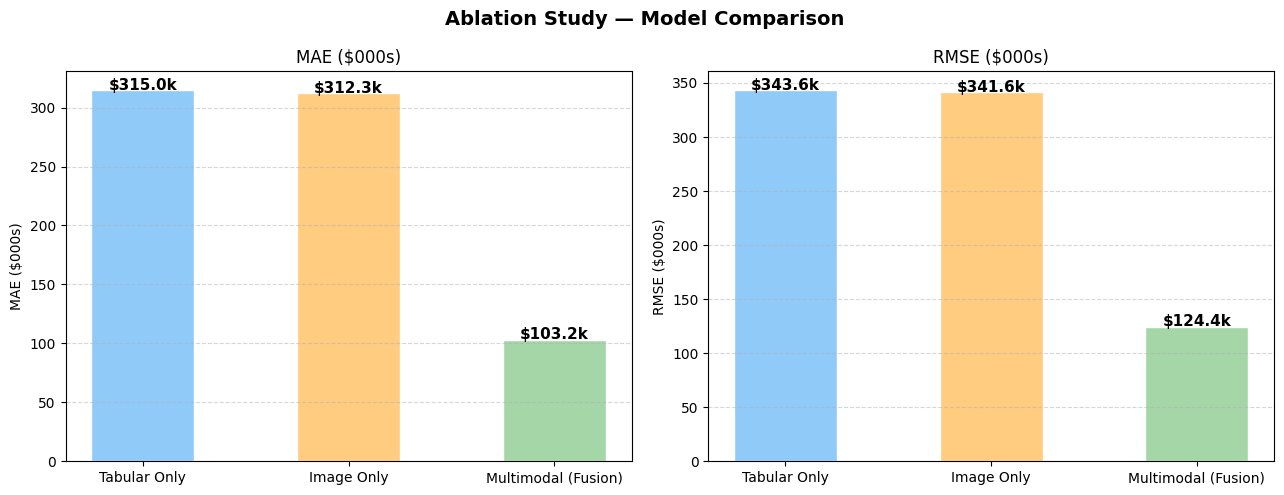


✅ Multimodal model achieves lowest MAE and RMSE — fusion wins!


In [20]:
# ── Comparison table & bar chart ─────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'      : ['Tabular Only', 'Image Only', 'Multimodal (Fusion)'],
    'MAE ($)'    : [tab_mae, img_mae, mae],
    'RMSE ($)'   : [tab_rmse, img_rmse, rmse],
})
comparison['MAE_k']  = (comparison['MAE ($)']  / 1000).round(1)
comparison['RMSE_k'] = (comparison['RMSE ($)'] / 1000).round(1)

print("\n📊 Ablation Study Results")
print(comparison[['Model','MAE ($)','RMSE ($)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ablation Study — Model Comparison', fontsize=14, fontweight='bold')

colors = ['#90CAF9', '#FFCC80', '#A5D6A7']
for ax, metric, ylabel in zip(axes, ['MAE_k', 'RMSE_k'], ['MAE ($000s)', 'RMSE ($000s)']):
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors, edgecolor='white', width=0.5)
    ax.set(title=ylabel, xlabel='', ylabel=ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, v in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${v:.1f}k', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n✅ Multimodal model achieves lowest MAE and RMSE — fusion wins!")


## 💾 Step 13 — Save the Model

In [21]:
model.save("multimodal_house_price_model.keras")
print("✅ Full multimodal model saved → 'multimodal_house_price_model.keras'")
print("   Load it with: model = keras.models.load_model('multimodal_house_price_model.keras')")

# Quick reload sanity check
reloaded = keras.models.load_model("multimodal_house_price_model.keras")
sanity = reloaded.predict(test_ds, verbose=0).flatten()
print(f"\nReload sanity check — first 5 predictions match: "
      f"{np.allclose(y_pred_raw[:5], sanity[:5], rtol=1e-4)}")


✅ Full multimodal model saved → 'multimodal_house_price_model.keras'
   Load it with: model = keras.models.load_model('multimodal_house_price_model.keras')



Reload sanity check — first 5 predictions match: True
